# AMR Array Explorer
This notebook walks through building, refining, differentiating, and visualising an `AMRArray` interactively.

Run cells one at a time with **Shift+Enter**. State persists between cells, so you can go back and tweak any parameter and re-run from that point.

## 1. Imports and setup

In [1]:
import sys, math
import numpy as np
import matplotlib.pyplot as plt

# Make sure the source files are on the path.
# Adjust this if your files live somewhere else.
sys.path.insert(0, '.')

from amr_array                   import AMRArray
from fd_deriv                    import FDDeriv
from refine_from_previous_level  import refine_from_previous_level, reset_refine_cache
from compute_derivative          import compute_derivative, reset_derivative_cache
from compute_derivative_variants import compute_derivative_no_sync, reset_derivative_variant_cache

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi']     = 110
print('Ready.')

Ready.


## 2. Problem definition
Edit the parameters here and re-run the rest of the notebook to see the effect.

In [2]:
class ProbDef:
    n_coarse    = 21       # coarse grid points
    n_comp      = 1        # number of solution components
    max_no_levs = 4        # maximum refinement levels
    ref_fac     = 4        # refinement factor between levels
    x_left      = 0.0
    x_right     = 1.0

# Test function and its derivatives
k      = 2 * math.pi
f_func  = lambda x: np.sin(k * x)
df_func = lambda x: k  * np.cos(k * x)
d2f_func = lambda x: -k**2 * np.sin(k * x)

prob = ProbDef()
print(f'Coarse dx = {(prob.x_right - prob.x_left) / (prob.n_coarse - 1):.4f}')
print(f'Level-1 dx = {(prob.x_right - prob.x_left) / (prob.n_coarse - 1) / prob.ref_fac:.5f}')

Coarse dx = 0.0500
Level-1 dx = 0.01250


## 3. Build a coarse-only AMRArray

In [3]:
amr = AMRArray(prob)
amr.set_coarse_array(f_func(amr.x_coarse), comp=0)

# Quick look at key attributes
print(amr)
print(f'x_coarse shape : {amr.x_coarse.shape}')
print(f'f_coarse shape : {amr.f_coarse.shape}')
print(f'n_ref          : {amr.n_ref}')
print(f'dx             : {amr.dx}')

AMRArray(n_coarse=21, n_comp=1, max_no_levs=4, ref_fac=4, ref_levs_so_far=0)
x_coarse shape : (21,)
f_coarse shape : (21, 1)
n_ref          : [ 1  4 16 64]
dx             : [0.05       0.0125     0.003125   0.00078125]


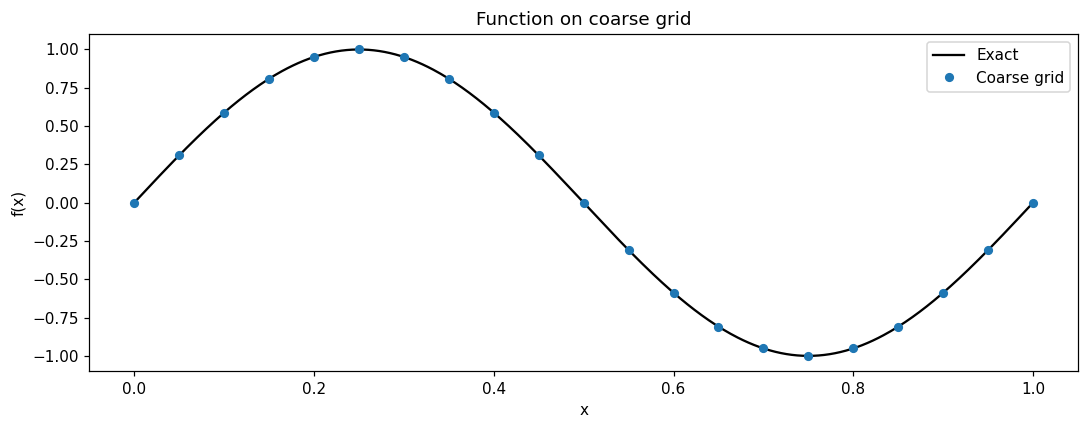

In [4]:
# Plot the coarse function
x_exact = np.linspace(prob.x_left, prob.x_right, 500)

fig, ax = plt.subplots()
ax.plot(x_exact, f_func(x_exact), 'k-',  lw=1.5, label='Exact')
ax.plot(amr.x_coarse, amr.f_coarse[:, 0], 'o', ms=5, label='Coarse grid')
ax.set(title='Function on coarse grid', xlabel='x', ylabel='f(x)')
ax.legend()
plt.tight_layout()

## 4. Add one level of refinement
Refine the middle third of the domain.

In [5]:
reset_refine_cache()
ORDER = 4

# Choose which coarse intervals to refine (0-indexed)
refine_start = prob.n_coarse // 3
refine_end   = 2 * prob.n_coarse // 3

for i in range(refine_start, refine_end):
    amr = refine_from_previous_level(amr, index=i, level=1, order=ORDER)

amr.determine_refinement_segments()

print(f'ref_levs_so_far : {amr.ref_levs_so_far}')
print(f'n_ref_seg       : {amr.n_ref_seg}')
print(f'Refined coarse indices: {refine_start} to {refine_end - 1}')
print(f'Segment start   : {amr.beg_ref_seg[0, 0]}')
print(f'Segment end     : {amr.end_ref_seg[0, 0]}')

ref_levs_so_far : 1
n_ref_seg       : [1 0 0 0]
Refined coarse indices: 7 to 13
Segment start   : 7
Segment end     : 13


In [6]:
# Inspect the refined data at one coarse point — try changing the index
idx = refine_start + 2
fine_vals = amr.get_refinement_at(idx, 1)
fine_x    = amr.x_coord.get((idx, 1))

print(f'Fine data at coarse index {idx}:')
print(f'  x_coord : {fine_x}')
print(f'  f_arr   :\n{fine_vals}')

Fine data at coarse index 9:
  x_coord : [0.45   0.4625 0.475  0.4875 0.5   ]
  f_arr   :
[[3.09016994e-01]
 [2.33467576e-01]
 [1.56468441e-01]
 [7.84864422e-02]
 [1.22464680e-16]]


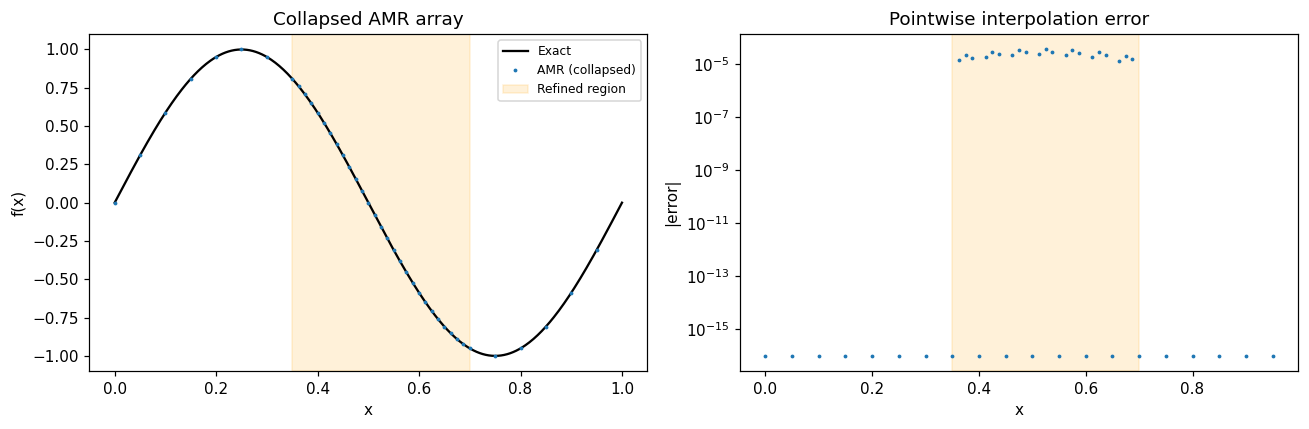

In [7]:
# Collapse to a flat array and plot both levels
x_col, f_col = amr.collapse_array(comp=0, start=0, finish=prob.n_coarse - 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full domain
axes[0].plot(x_exact, f_func(x_exact), 'k-', lw=1.5, label='Exact')
axes[0].plot(x_col, f_col, '.', ms=3, label='AMR (collapsed)')
axes[0].axvspan(amr.x_coarse[refine_start], amr.x_coarse[refine_end],
                alpha=0.15, color='orange', label='Refined region')
axes[0].set(title='Collapsed AMR array', xlabel='x', ylabel='f(x)')
axes[0].legend(fontsize=8)

# Right: error
err_col = np.abs(f_col - f_func(x_col))
axes[1].semilogy(x_col, err_col + 1e-16, '.', ms=3)
axes[1].axvspan(amr.x_coarse[refine_start], amr.x_coarse[refine_end],
                alpha=0.15, color='orange')
axes[1].set(title='Pointwise interpolation error', xlabel='x', ylabel='|error|')

plt.tight_layout()

## 5. Compute the first derivative

In [8]:
reset_derivative_cache()
amr_d1 = compute_derivative(amr, order=ORDER, n_deriv=1)

# Coarse-level error
fo2 = ORDER // 2
numeric  = amr_d1.f_coarse[:, 0]
analytic = df_func(amr.x_coarse)
err_coarse = np.abs(numeric - analytic)
print(f'Coarse first-deriv max error (interior): {np.max(err_coarse[fo2:-fo2]):.3e}')

# Fine-level error
fine_errs = []
for i in range(prob.n_coarse - 1):
    arr = amr_d1.f_arr.get((i, 1))
    xc  = amr.x_coord.get((i, 1))
    if arr is not None and xc is not None:
        fine_errs.append(np.max(np.abs(arr[:, 0] - df_func(xc))))

if fine_errs:
    print(f'Fine  first-deriv max error           : {max(fine_errs):.3e}')

Coarse first-deriv max error (interior): 1.645e-03
Fine  first-deriv max error           : 1.890e-03


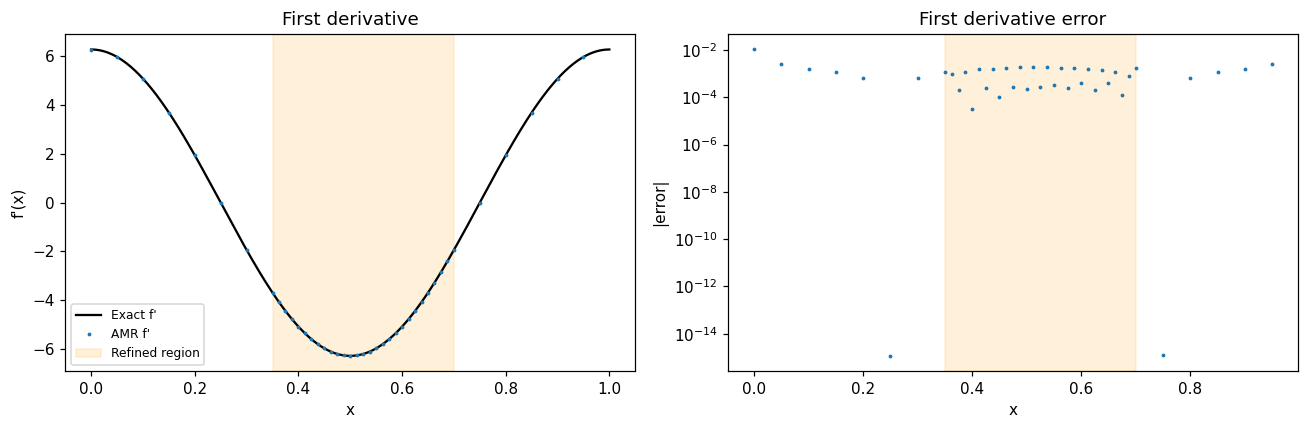

In [9]:
# Collapse derivative and plot
x_d1, f_d1 = amr_d1.collapse_array(comp=0, start=0, finish=prob.n_coarse - 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_exact, df_func(x_exact), 'k-', lw=1.5, label="Exact f'")
axes[0].plot(x_d1, f_d1, '.', ms=3, label="AMR f'")
axes[0].axvspan(amr.x_coarse[refine_start], amr.x_coarse[refine_end],
                alpha=0.15, color='orange', label='Refined region')
axes[0].set(title='First derivative', xlabel='x', ylabel="f'(x)")
axes[0].legend(fontsize=8)

axes[1].semilogy(x_d1, np.abs(f_d1 - df_func(x_d1)) + 1e-16, '.', ms=3)
axes[1].axvspan(amr.x_coarse[refine_start], amr.x_coarse[refine_end],
                alpha=0.15, color='orange')
axes[1].set(title='First derivative error', xlabel='x', ylabel="|error|")

plt.tight_layout()

## 6. Compute the second derivative

Coarse second-deriv max error (interior): 3.948e-01


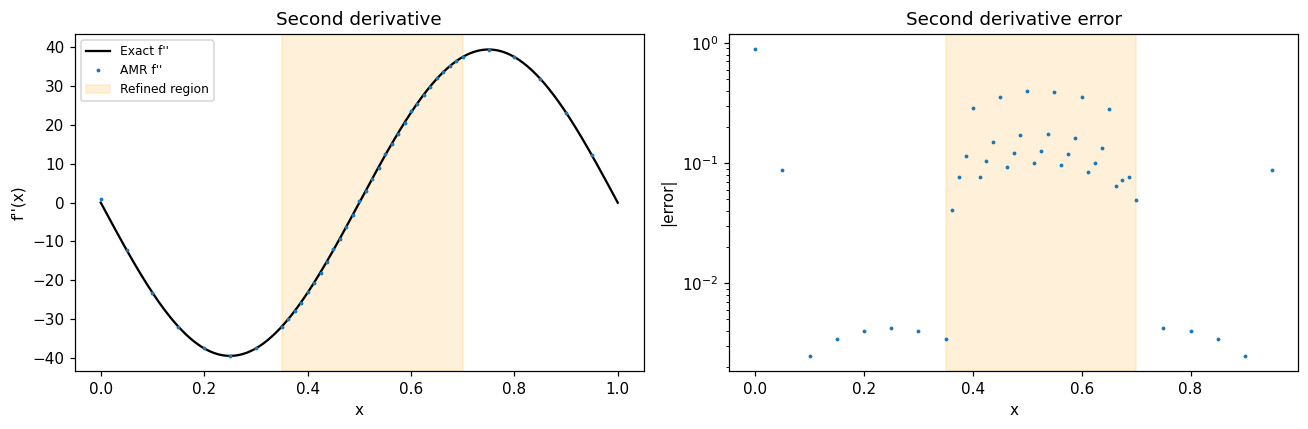

In [10]:
reset_derivative_cache()
amr_d2 = compute_derivative(amr, order=ORDER, n_deriv=2)

numeric2  = amr_d2.f_coarse[:, 0]
analytic2 = d2f_func(amr.x_coarse)
err2 = np.abs(numeric2 - analytic2)
print(f'Coarse second-deriv max error (interior): {np.max(err2[fo2:-fo2]):.3e}')

x_d2, f_d2 = amr_d2.collapse_array(comp=0, start=0, finish=prob.n_coarse - 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_exact, d2f_func(x_exact), 'k-', lw=1.5, label="Exact f''")
axes[0].plot(x_d2, f_d2, '.', ms=3, label="AMR f''")
axes[0].axvspan(amr.x_coarse[refine_start], amr.x_coarse[refine_end],
                alpha=0.15, color='orange', label='Refined region')
axes[0].set(title='Second derivative', xlabel='x', ylabel="f''(x)")
axes[0].legend(fontsize=8)

axes[1].semilogy(x_d2, np.abs(f_d2 - d2f_func(x_d2)) + 1e-16, '.', ms=3)
axes[1].axvspan(amr.x_coarse[refine_start], amr.x_coarse[refine_end],
                alpha=0.15, color='orange')
axes[1].set(title='Second derivative error', xlabel='x', ylabel="|error|")

plt.tight_layout()

## 7. Convergence study
Verify that the error scales as $O(h^p)$ by doubling the coarse grid size.

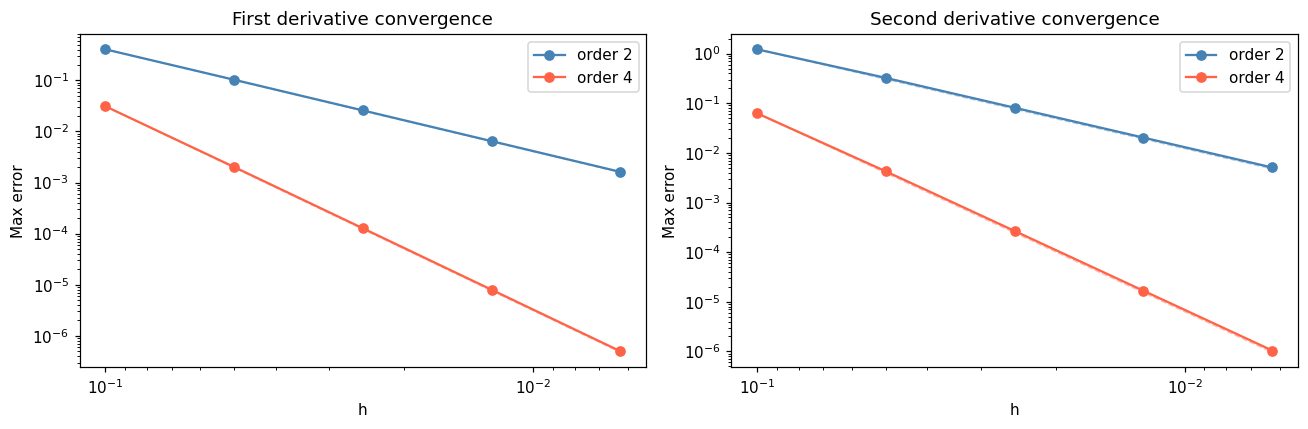

In [11]:
def coarse_deriv_error(n_coarse, order, n_deriv):
    """Return max interior error for a coarse-only AMR at given resolution."""
    class P:
        n_comp = 1; max_no_levs = 2; ref_fac = 2; x_left = 0.0; x_right = 1.0
    P.n_coarse = n_coarse

    a = AMRArray(P())
    a.set_coarse_array(f_func(a.x_coarse), comp=0)
    a.determine_refinement_segments()

    reset_derivative_cache()
    ad = compute_derivative(a, order=order, n_deriv=n_deriv)
    reset_derivative_cache()

    fo2    = order // 2
    exact  = (df_func if n_deriv == 1 else d2f_func)(a.x_coarse)
    return np.max(np.abs(ad.f_coarse[fo2:-fo2, 0] - exact[fo2:-fo2]))


grid_sizes = [11, 21, 41, 81, 161]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for order, color in [(2, 'steelblue'), (4, 'tomato')]:
    for ax, n_deriv, label in zip(axes, [1, 2], ["First derivative", "Second derivative"]):
        errs = [coarse_deriv_error(n, order, n_deriv) for n in grid_sizes]
        hs   = [1.0 / (n - 1) for n in grid_sizes]
        ax.loglog(hs, errs, 'o-', color=color, label=f'order {order}')
        # Reference slope
        ax.loglog(hs, [errs[0] * (h / hs[0])**order for h in hs],
                  '--', color=color, alpha=0.4, lw=1)

for ax, title in zip(axes, ["First derivative", "Second derivative"]):
    ax.set(title=f'{title} convergence', xlabel='h', ylabel='Max error')
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()

## 8. Sandbox
Use this cell to experiment freely — all the objects defined above are still in memory.

In [12]:
# Example: inspect is_ref flags
import pandas as pd

df = pd.DataFrame(
    amr.is_ref,
    columns=[f'level {l}' for l in range(amr.max_no_levs)]
)
df.index.name = 'coarse index'
df[df.any(axis=1)]   # show only refined rows

,level 0,level 1,level 2,level 3
coarse index,,,,
7,True,False,False,False
8,True,False,False,False
9,True,False,False,False
10,True,False,False,False
11,True,False,False,False
12,True,False,False,False
13,True,False,False,False


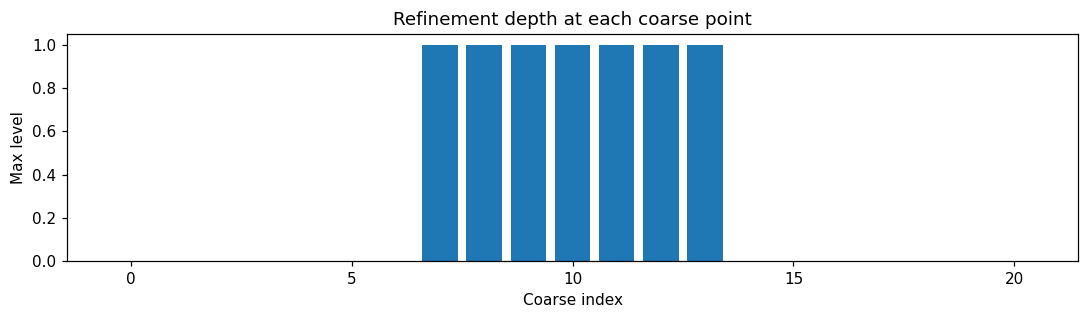

In [13]:
# Example: inspect coarse_lev_depth as a bar chart
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(amr.n_coarse), amr.coarse_lev_depth)
ax.set(title='Refinement depth at each coarse point',
       xlabel='Coarse index', ylabel='Max level')
plt.tight_layout()